# Identify frequent item sets using the Apriori algorithm for a given transaction data set.

Association rule mining on a small transaction dataset using `mlxtend`.

One - Hot Encoded Data
    Beer  Bread  Butter  Cookies  Diaper   Milk
0  False   True    True    False   False   True
1  False   True    True    False   False  False
2   True  False   False     True    True  False
3  False   True    True    False    True   True
4   True  False   False    False    True  False

Frequency Itemsets
   support               itemsets
0      0.4                 (Beer)
1      0.6                (Bread)
2      0.6               (Butter)
3      0.6               (Diaper)
4      0.4                 (Milk)
5      0.4         (Diaper, Beer)
6      0.6        (Bread, Butter)
7      0.4          (Bread, Milk)
8      0.4         (Milk, Butter)
9      0.4  (Bread, Milk, Butter)

Association Rules
      antecedents      consequents  support  confidence      lift
0          (Beer)         (Diaper)      0.4         1.0  1.666667
1         (Bread)         (Butter)      0.6         1.0  1.666667
2        (Butter)          (Bread)      0.6         1.0  1.666667
3          (

C:\Users\Levono\AppData\Local\Temp\ipykernel_12340\2463311382.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='support', y='itemsets', data=top_itemsets, palette="viridis")


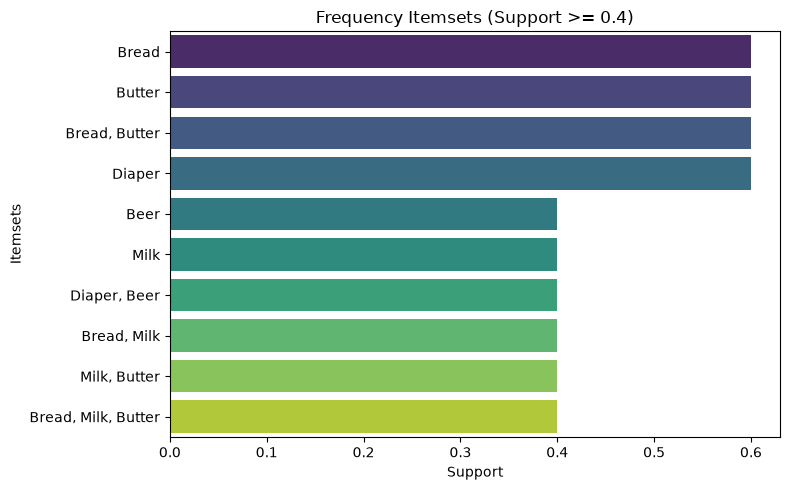

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
dataset = [['Bread','Butter','Milk'],
          ['Bread','Butter'],
           ['Beer','Cookies','Diaper'],
           ['Milk','Diaper','Bread','Butter'],
          ['Beer','Diaper']]

te = TransactionEncoder()
te_array = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_array, columns=te.columns_) # pyright: ignore[reportArgumentType]
print("One - Hot Encoded Data")
print(df)

frequent_itemsets = apriori(df, min_support=0.4, use_colnames=True)
print("\nFrequency Itemsets")
print(frequent_itemsets)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)
print("\nAssociation Rules")
print(rules[['antecedents','consequents','support','confidence','lift']])

frequent_itemsets['itemsets'] = frequent_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))
top_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='support', y='itemsets', data=top_itemsets, palette="viridis")
plt.title('Frequency Itemsets (Support >= 0.4)')
plt.xlabel('Support')
plt.ylabel('Itemsets')
plt.tight_layout()
plt.show()